# Loading merged

In [124]:
import pandas as pd
import os
from pathlib import Path
from dotenv import load_dotenv

# --- 1. Define Paths ---
def load_environment():
    """Load environment variables and return the output path."""
    load_dotenv(Path("../utils/.env"))  
    return {
        "CLEANED_DATASET_FOLDER": os.getenv("CLEANEDDATASET_FOLDER"),
        "PREPROCESSED_LANDCOVER_FOLDER": os.getenv("PREPROCESSED_LANDCOVER_FOLDER"),
        "PREPROCESSED_DATASET_FOLDER": os.getenv("PREPROCESSED_DATASET_FOLDER"),
        "MERGED_DATASET": os.getenv("MergedDatasets") # Assuming 'cleaned_dataset_folder' is where you want the final merged file.
    }

folders = load_environment()
input_dir = folders["CLEANED_DATASET_FOLDER"]
preprocessed_landcover_folder = folders["PREPROCESSED_LANDCOVER_FOLDER"]
preprocessed_dataset_folder = folders["PREPROCESSED_DATASET_FOLDER"]
final_output_dir = folders["MERGED_DATASET"]


# Note: Based on your last successful output, the file name should be final_MERGED_DATASET.parquet.
# I will use the name you provided now, landcover_ElevSoilClimate.parquet, but double-check the path if it fails.
PARQUET_PATH = os.path.join(final_output_dir, "landcover_ElevSoilClimate.parquet") 

# --- 2. Load the DataFrame ---
try:
    # Use pandas.read_parquet to load the file
    df_merged = pd.read_parquet(PARQUET_PATH)
    
    print(f"✅ Successfully loaded {os.path.basename(PARQUET_PATH)}.")
    
except FileNotFoundError:
    print(f"❌ Error: File not found at {PARQUET_PATH}. Check the filename and path.")
except Exception as e:
    print(f"❌ An error occurred while reading the Parquet file: {e}")

# --- 3. View the Content ---
if 'df_merged' in locals():
    print("\n## 📊 Data Summary")
    print(f"Shape: **{df_merged.shape}** (rows, columns)")
    print("-" * 30)
    
    print("\n## 🔎 Head of Data:")
    print(df_merged.head())
    
    print("\n## 📝 Column Information:")
    # Display data types and non-null counts
    df_merged.info(verbose=False)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\

AttributeError: _ARRAY_API not found

✅ Successfully loaded landcover_ElevSoilClimate.parquet.

## 📊 Data Summary
Shape: **(23322, 47)** (rows, columns)
------------------------------

## 🔎 Head of Data:
  match_type   distance_m  cell_id  \
0    nearest  5730.516569        0   
1    nearest  4333.944079        1   
2    nearest  3326.267859        2   
3    nearest  3329.154720        3   
4    nearest  3332.056800        4   

                                            geometry  \
0  MULTIPOLYGON (((-8.568909 27.268147000000116, ...   
1  MULTIPOLYGON (((-8.568909 27.368147000000118, ...   
2  MULTIPOLYGON (((-8.568909 27.46814700000012, -...   
3  MULTIPOLYGON (((-8.568909 27.56814700000012, -...   
4  MULTIPOLYGON (((-8.568909 27.668147000000122, ...   

                                             month_1  \
0  [np.float64(8.5), np.float64(22.0), np.float64...   
1  [np.float64(8.0), np.float64(22.0), np.float64...   
2  [np.float64(8.5), np.float64(22.0), np.float64...   
3  [np.float64(8.0), np.float64(22.0), np.fl

In [125]:
df_merged.columns

Index(['match_type', 'distance_m', 'cell_id', 'geometry', 'month_1', 'month_2',
       'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
       'month_9', 'month_10', 'month_11', 'month_12', 'x', 'y',
       'HWSD2_SMU_ID_soil', 'COARSE_soil', 'SAND_soil', 'SILT_soil',
       'CLAY_soil', 'BULK_soil', 'REF_BULK_soil', 'ORG_CARBON_soil',
       'PH_WATER_soil', 'TOTAL_N_soil', 'CEC_SOIL_soil', 'CEC_CLAY_soil',
       'CEC_EFF_soil', 'TEB_soil', 'BSAT_soil', 'ALUM_SAT_soil', 'ESP_soil',
       'TCARBON_EQ_soil', 'GYPSUM_soil', 'ELEC_COND_soil', 'elevation',
       'area_log', 'lcc_Bare lands', 'lcc_Croplands', 'lcc_Forests',
       'lcc_Grasslands', 'lcc_Unclassified', 'lcc_Vegetation',
       'lcc_Water bodies'],
      dtype='object')

# loading fire

In [126]:
import geopandas as gpd

# Define the expected filename for your fire data
# You'll need to replace 'fire_data.geojson' with the actual name of your file.
preprocessed_fire_folder = os.path.join(preprocessed_dataset_folder, "FireDataset")
FIRE_GEOJSON_PATH = os.path.join(preprocessed_fire_folder, "fire_type_1.geojson") 

# --- 2. Load the GeoJSON ---

try:
    # Use geopandas.read_file() to load the GeoJSON
    fire_gdf = gpd.read_file(FIRE_GEOJSON_PATH)
    
    print(f"✅ Successfully loaded fire data from {os.path.basename(FIRE_GEOJSON_PATH)}.")
    
except FileNotFoundError:
    print(f"❌ Error: Fire GeoJSON file not found at {FIRE_GEOJSON_PATH}. Please verify the path and filename.")
except Exception as e:
    print(f"❌ An error occurred while reading the GeoJSON file: {e}")

# --- 3. View the Content (if successful) ---

if 'fire_gdf' in locals():
    print("\n## 📊 Fire Data Summary")
    print(f"Shape: **{fire_gdf.shape}** (rows, columns)")
    print(f"CRS (Coordinate Reference System): **{fire_gdf.crs}**")
    print("-" * 30)
    
    print("\n## 🔎 Head of Fire GeoDataFrame:")
    print(fire_gdf.head())
    
    print("\n## 📝 Data Types:")
    fire_gdf.info(verbose=False)

    print("\n## 🗺️ Fire columns:")
    print(fire_gdf.columns)

✅ Successfully loaded fire data from fire_type_1.geojson.

## 📊 Fire Data Summary
Shape: **(14216, 2)** (rows, columns)
CRS (Coordinate Reference System): **EPSG:4326**
------------------------------

## 🔎 Head of Fire GeoDataFrame:
   fire                  geometry
0     1  POINT (5.53337 35.70751)
1     1  POINT (6.46961 32.13579)
2     1   POINT (6.9763 32.35563)
3     1  POINT (9.39581 28.19791)
4     1  POINT (9.49323 28.12826)

## 📝 Data Types:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14216 entries, 0 to 14215
Columns: 2 entries, fire to geometry
dtypes: geometry(1), int32(1)
memory usage: 166.7 KB

## 🗺️ Fire columns:
Index(['fire', 'geometry'], dtype='object')


# Slight Analysis

In [127]:
# viewing if there's missing data in df_merged
print("\n## Missing Data in Merged DataFrame:")
if 'df_merged' in locals():
    missing_data = df_merged.isnull().sum()
    print(missing_data[missing_data > 0])

    # print("\n## rows with missing data:")
    # print(df_merged[df_merged.isnull().any(axis=1)])




## Missing Data in Merged DataFrame:
elevation     19
area_log     133
dtype: int64


In [128]:
# view area_log and elevation columns
print("\n## Viewing 'area_log' and 'elevation' columns:")
if 'df_merged' in locals():
    print(df_merged[['area_log', 'elevation']].head())


## Viewing 'area_log' and 'elevation' columns:
    area_log  elevation
0  26.539949      452.0
1  26.539949      460.0
2  26.539949      459.0
3  26.539949      465.0
4  26.539949      470.0


In [129]:
print("length of merged dataset",len(df_merged))
print("percentage of missing data in area_log:", df_merged['area_log'].isnull().mean()*100)
print("percentage of missing data in elevation:", df_merged['elevation'].isnull().mean()*100)

length of merged dataset 23322
percentage of missing data in area_log: 0.570276991681674
percentage of missing data in elevation: 0.08146814166881056


In [130]:
#  low percentage --> drop
# Assuming your merged dataset is stored in the variable 'df_merged'
print(f"Original length: {len(df_merged)}")

# Delete rows where *either* area_log or elevation is missing
df_cleaned = df_merged.dropna(subset=['area_log', 'elevation'])

# Calculate how many rows were dropped
rows_dropped = len(df_merged) - len(df_cleaned)

print(f"Cleaned length: {len(df_cleaned)}")
print(f"Rows dropped: {rows_dropped}")

Original length: 23322
Cleaned length: 23180
Rows dropped: 142


In [131]:
df_cleaned.head()

,match_type,distance_m,cell_id,geometry,month_1,month_2,month_3,month_4,month_5,month_6,...,ELEC_COND_soil,elevation,area_log,lcc_Bare lands,lcc_Croplands,lcc_Forests,lcc_Grasslands,lcc_Unclassified,lcc_Vegetation,lcc_Water bodies
0,nearest,5730.516569,0,"MULTIPOLYGON (((-8.568909 27.268147000000116, ...","[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(20.0), np.float64(33.75), np.float...","[np.float64(23.0), np.float64(36.75), np.float...",...,1.0,452.0,26.539949,True,False,False,False,False,False,False
1,nearest,4333.944079,1,"MULTIPOLYGON (((-8.568909 27.368147000000118, ...","[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(19.25), np.float64(33.25), np.floa...","[np.float64(22.75), np.float64(36.25), np.floa...",...,1.0,460.0,26.539949,True,False,False,False,False,False,False
2,nearest,3326.267859,2,"MULTIPOLYGON (((-8.568909 27.46814700000012, -...","[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(24.75), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.5), np.float64(31.5), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...",...,1.0,459.0,26.539949,True,False,False,False,False,False,False
3,nearest,3329.154720,3,"MULTIPOLYGON (((-8.568909 27.56814700000012, -...","[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.75), np.float64(24.0), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...",...,1.0,465.0,26.539949,True,False,False,False,False,False,False
4,nearest,3332.056800,4,"MULTIPOLYGON (((-8.568909 27.668147000000122, ...","[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.0), np.float64(24.0), np.float6...","[np.float64(12.5), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...",...,1.0,470.0,26.539949,True,False,False,False,False,False,False


# Spatial Join

In [132]:
import geopandas as gpd
import pandas as pd
from shapely import wkt 

# Safely convert WKT strings to Shapely objects
def safe_wkt_load(wkt_string):
    """Safely loads a WKT string, handling NaN or invalid strings."""
    if pd.isna(wkt_string) or wkt_string is None:
        return None
    try:
        return wkt.loads(wkt_string)
    except Exception:
        # For data processing, you might want to log this but return None to continue
        return None

# Apply the safe function to your geometry column
df_cleaned['geometry'] = df_cleaned['geometry'].apply(safe_wkt_load)

# Convert the cleaned DataFrame into a GeoDataFrame
# Assuming 'fire_gdf' has the correct CRS you want to use
if not isinstance(df_cleaned, gpd.GeoDataFrame):
    df_cleaned = gpd.GeoDataFrame(
        df_cleaned,
        geometry='geometry',
        crs=fire_gdf.crs
        
    )

C:\Users\moous\AppData\Local\Temp\ipykernel_26832\1279940239.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['geometry'] = df_cleaned['geometry'].apply(safe_wkt_load)


In [133]:
# Check the current CRS of both
print(f"df_cleaned CRS: {df_cleaned.crs}")
print(f"fire_gdf CRS: {fire_gdf.crs}")

# If they are different, align them (e.g., to the CRS of df_cleaned)
if df_cleaned.crs != fire_gdf.crs:
    fire_gdf = fire_gdf.to_crs(df_cleaned.crs)
    print("CRS fixed on fire_gdf.")

df_cleaned CRS: EPSG:4326
fire_gdf CRS: EPSG:4326


In [134]:
print("lenth of cleaned dataset",len(df_cleaned))
print("lenth of fire dataset",len(fire_gdf))

lenth of cleaned dataset 23180
lenth of fire dataset 14216


In [135]:
# Check for invalid geometries in the cleaned data
print(f"Invalid geometries in df_cleaned: {df_cleaned.geometry.is_valid.sum()}")

Invalid geometries in df_cleaned: 23180


In [136]:
# Attempt to repair all invalid geometries using buffer(0)
# Note: This operation can take a few minutes depending on the dataset size.
print("Attempting to repair all invalid geometries...")

df_cleaned.geometry = df_cleaned.geometry.apply(
    lambda geom: geom.buffer(0) if geom is not None and not geom.is_valid else geom
)

# Re-check the number of invalid geometries after repair
invalid_count_after = (~df_cleaned.geometry.is_valid).sum()
print(f"Invalid geometries remaining after repair: {invalid_count_after}")

Attempting to repair all invalid geometries...
Invalid geometries remaining after repair: 0


In [137]:
# 3. Perform the Spatial Join
df_merged_and_fire = gpd.sjoin(
    df_cleaned, 
    fire_gdf[['fire', 'geometry']],
    how='left',
    # Use 'within' or 'intersects'. 'within' is best for Point-in-Polygon.
    predicate='intersects' 
)

print(f"Initial merged shape: {df_merged_and_fire.shape}. Expecting duplicates if a polygon had multiple fires.")

Initial merged shape: (36041, 49). Expecting duplicates if a polygon had multiple fires.


In [138]:
#  fill nan values in 'fire' column with 0
df_merged_and_fire['fire'] = df_merged_and_fire['fire'].fillna(0).astype(int)

In [139]:
# number of rows where fire == 1 and fire == 0
print("Number of rows with fire == 1:", len(df_merged_and_fire[df_merged_and_fire['fire'] == 1]))
print("Number of rows with fire == 0:", len(df_merged_and_fire[df_merged_and_fire['fire'] == 0]))

Number of rows with fire == 1: 14205
Number of rows with fire == 0: 21836


In [140]:
df_merged_and_fire.head()

,match_type,distance_m,cell_id,geometry,month_1,month_2,month_3,month_4,month_5,month_6,...,area_log,lcc_Bare lands,lcc_Croplands,lcc_Forests,lcc_Grasslands,lcc_Unclassified,lcc_Vegetation,lcc_Water bodies,index_right,fire
0,nearest,5730.516569,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27...","[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(20.0), np.float64(33.75), np.float...","[np.float64(23.0), np.float64(36.75), np.float...",...,26.539949,True,False,False,False,False,False,False,NaN,0
1,nearest,4333.944079,1,"MULTIPOLYGON (((-8.56891 27.36815, -8.56891 27...","[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(19.25), np.float64(33.25), np.floa...","[np.float64(22.75), np.float64(36.25), np.floa...",...,26.539949,True,False,False,False,False,False,False,NaN,0
2,nearest,3326.267859,2,"MULTIPOLYGON (((-8.56891 27.46815, -8.56891 27...","[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(24.75), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.5), np.float64(31.5), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...",...,26.539949,True,False,False,False,False,False,False,NaN,0
3,nearest,3329.154720,3,"MULTIPOLYGON (((-8.56891 27.56815, -8.56891 27...","[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.75), np.float64(24.0), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...",...,26.539949,True,False,False,False,False,False,False,NaN,0
4,nearest,3332.056800,4,"MULTIPOLYGON (((-8.56891 27.66815, -8.56891 27...","[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.0), np.float64(24.0), np.float6...","[np.float64(12.5), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...",...,26.539949,True,False,False,False,False,False,False,NaN,0


The extra rows are the duplicates—multiple fire points falling inside a single polygon.

### 💡 Explaining Step 3: Aggregation


The purpose of Step 3 is to resolve the issue of duplicate rows created by the spatial join (gpd.sjoin) and produce a final, clean dataset where each polygon (cell) is represented by exactly one row.

Why Duplicates Occur
Input: You had two GeoDataFrames:

df_cleaned: Areas (MULTIPOLYGONs). Each row is a unique cell/polygon.

fire_gdf: Fire events (POINTS).

Spatial Join: When the gpd.sjoin function runs with predicate='within', it matches every fire point to the polygon it falls inside.

The Result: If a single large polygon contains, for example, 10 separate fire points, the spatial join will create 10 rows for that polygon—one row for each fire event. While the geometry and environmental attributes (like elevation, soil, etc.) are identical across these 10 rows, the row is technically a duplicate relative to the original unique cell.

The Aggregation Solution
To fix this, we use the .groupby().agg() method in Pandas/GeoPandas.

The goal is to answer a binary question for each polygon: Did a fire occur in this polygon, yes or no?

Group By Index:

df_merged_and_fire.groupby(df_merged_and_fire.index): This groups the joined data using the index of the original df_cleaned GeoDataFrame. Since df_cleaned had one unique index value per polygon, this groups all the duplicate rows belonging to the same polygon together.

Define Aggregation Logic (agg_dict):

For the fire column: We use 'max'.

If a polygon had no fires, the fire column (from the left join) is NaN, which will eventually be filled to 0.

If a polygon had one or more fires, the fire column will contain at least one 1. The maximum of any number of 1s is 1.

Result: The aggregated fire column becomes a clean binary indicator: 1 = Fire Occurred, 0 = No Fire Occurred.

For all other attribute columns (area_log, elevation, soil types, etc.): We use 'first'. Since these attributes were identical across all duplicate rows for the same polygon, taking the first value effectively preserves the correct, unique attribute for that polygon.

For the geometry column: We also use 'first' to retain the correct MULTIPOLYGON boundary for the cell.

Final Cleanup:

df_final['fire'].fillna(0).astype(int): The final step handles the no-fire cases. For polygons that had zero fire events, the left join left the fire column as NaN. This line fills those NaNs with 0 and converts the column to an integer type.

The final output, df_final, is your desired dataset, featuring one row per unique cell/polygon, with all the environmental attributes and a single, clear fire (0 or 1) label.

In [141]:
# Define columns to aggregate. We want to keep all attributes ('first') 
# but check the 'fire' column ('max') to see if ANY fire occurred (0=No Fire, 1=Fire).

# Get a list of all columns from the original df_cleaned, excluding the geometry
agg_dict = {col: 'first' for col in df_cleaned.columns if col != 'geometry'}
# Add the 'fire' column aggregation (max=1 means at least one fire occurred)
agg_dict['fire'] = 'max' 
# Add geometry back
agg_dict['geometry'] = 'first' 

# Perform the aggregation
df_final = df_merged_and_fire.groupby(df_merged_and_fire.index).agg(agg_dict).reset_index(drop=True)

# Final cleanup: set missing 'fire' values (from the left join) to 0 and ensure it's a GeoDataFrame
df_final['fire'] = df_final['fire'].fillna(0).astype(int)

df_final = gpd.GeoDataFrame(df_final, geometry='geometry', crs=df_cleaned.crs)

print(f"Final aggregated shape: {df_final.shape}")
print("✅ Final Dataset (df_final) created and aggregated successfully!")
print("\n## 🔎 Sample of Final Merged Data:")
print(df_final[['cell_id', 'fire', 'area_log', 'geometry']].head())

Final aggregated shape: (23180, 48)
✅ Final Dataset (df_final) created and aggregated successfully!

## 🔎 Sample of Final Merged Data:
   cell_id  fire   area_log                                           geometry
0        0     0  26.539949  MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27...
1        1     0  26.539949  MULTIPOLYGON (((-8.56891 27.36815, -8.56891 27...
2        2     0  26.539949  MULTIPOLYGON (((-8.56891 27.46815, -8.56891 27...
3        3     0  26.539949  MULTIPOLYGON (((-8.56891 27.56815, -8.56891 27...
4        4     0  26.539949  MULTIPOLYGON (((-8.56891 27.66815, -8.56891 27...


In [142]:
df_final.columns

Index(['match_type', 'distance_m', 'cell_id', 'month_1', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'month_10', 'month_11', 'month_12', 'x', 'y', 'HWSD2_SMU_ID_soil',
       'COARSE_soil', 'SAND_soil', 'SILT_soil', 'CLAY_soil', 'BULK_soil',
       'REF_BULK_soil', 'ORG_CARBON_soil', 'PH_WATER_soil', 'TOTAL_N_soil',
       'CEC_SOIL_soil', 'CEC_CLAY_soil', 'CEC_EFF_soil', 'TEB_soil',
       'BSAT_soil', 'ALUM_SAT_soil', 'ESP_soil', 'TCARBON_EQ_soil',
       'GYPSUM_soil', 'ELEC_COND_soil', 'elevation', 'area_log',
       'lcc_Bare lands', 'lcc_Croplands', 'lcc_Forests', 'lcc_Grasslands',
       'lcc_Unclassified', 'lcc_Vegetation', 'lcc_Water bodies', 'fire',
       'geometry'],
      dtype='object')

In [143]:
df_final.head()

,match_type,distance_m,cell_id,month_1,month_2,month_3,month_4,month_5,month_6,month_7,...,area_log,lcc_Bare lands,lcc_Croplands,lcc_Forests,lcc_Grasslands,lcc_Unclassified,lcc_Vegetation,lcc_Water bodies,fire,geometry
0,nearest,5730.516569,0,"[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(20.0), np.float64(33.75), np.float...","[np.float64(23.0), np.float64(36.75), np.float...","[np.float64(27.75), np.float64(42.0), np.float...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27..."
1,nearest,4333.944079,1,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(19.25), np.float64(33.25), np.floa...","[np.float64(22.75), np.float64(36.25), np.floa...","[np.float64(27.0), np.float64(41.75), np.float...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.36815, -8.56891 27..."
2,nearest,3326.267859,2,"[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(24.75), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.5), np.float64(31.5), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.5), np.float6...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.46815, -8.56891 27..."
3,nearest,3329.154720,3,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.75), np.float64(24.0), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.56815, -8.56891 27..."
4,nearest,3332.056800,4,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.0), np.float64(24.0), np.float6...","[np.float64(12.5), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.66815, -8.56891 27..."


In [144]:
# number of rows where fire == 1 and fire == 0
print("Number of rows with fire == 1:", df_final[df_final['fire'] == 1].shape[0])
print("Number of rows with fire == 0:", df_final[df_final['fire'] == 0].shape[0])

Number of rows with fire == 1: 1344
Number of rows with fire == 0: 21836


# Saving the df_final

In [145]:
# save the final dataframe 
# Save to GeoJSON
output_path_geojson = f'{final_output_dir}\df_final_merged.geojson'
df_final.to_file(output_path_geojson, driver='GeoJSON')

print(f"✅ Data saved successfully to: {output_path_geojson}")

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\moous\AppData\Local\Temp\ipykernel_26832\3204100125.py:3: SyntaxWarning: invalid escape sequence '\d'
  output_path_geojson = f'{final_output_dir}\df_final_merged.geojson'


✅ Data saved successfully to: ../../MergedDatasets\df_final_merged.geojson


# Verification vizualisation

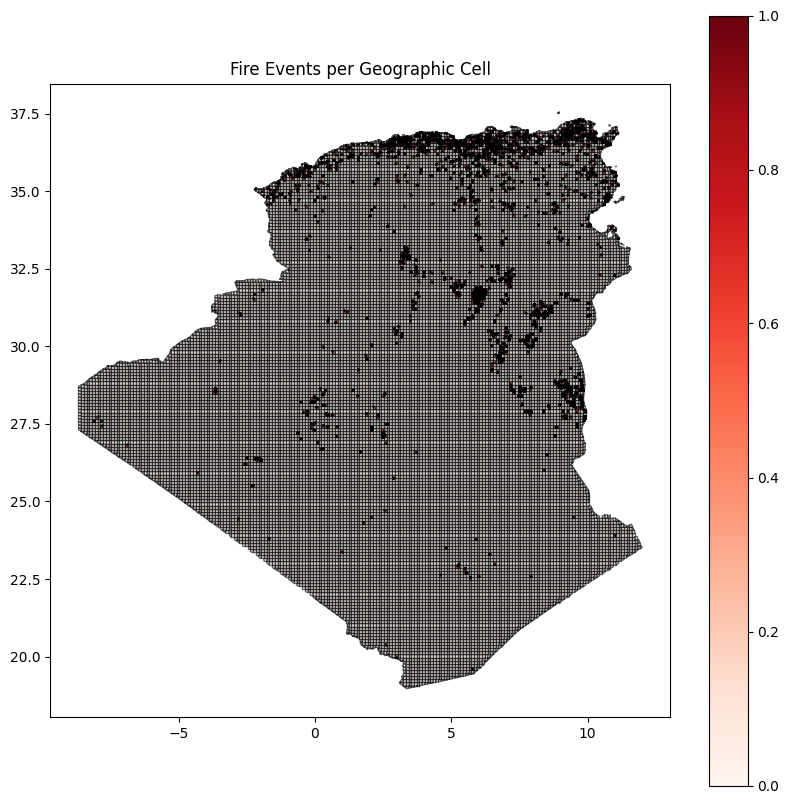

In [146]:
import matplotlib.pyplot as plt

# 1. Plot the polygons (df_final)
ax = df_final.plot(
    column='fire', # Color the polygons based on the 'fire' column (0 or 1)
    cmap='Reds',   # Use a red color map
    legend=True,
    figsize=(10, 10),
    alpha=0.6,
    edgecolor='black'
)

# 2. Add the fire points (optional, as fire=1 is already shown)
# We filter fire_gdf to only show points that matched a polygon (for context)
fire_gdf.plot(ax=ax, color='black', marker='o', markersize=1, alpha=0.8)

# Set the title and display the map
ax.set_title('Fire Events per Geographic Cell')
plt.show()